# Check consistency with julia script - Q,K,V from Julia

In [1]:
# imports
import numpy as np
import torch
import os
import sys
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)

from plm_gen_methods import generate_plm_n_save, generate_coords_n_save, generate_plm_vect_n_save
from seq_utils import read_tensor_from_txt, set_seed, letters_to_nums, modify_seq, find_target_seq, sequences_from_fasta
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
sys.path.pop(0)  # Removes the parent_dir from sys.path


'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM'

In [ ]:
def load_train_seqs_num(mac=True):
    family = 'jdoms_bacteria_train2'
    family = 'PF/PF00014'
    file_test_data = f'{family}.fasta'
    #filename = cwd + f'\CODE\DataAttentionDCA\jdoms\{family}.fasta'
    if not mac:
        file_test_data = r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
    train_sequences = sequences_from_fasta(file_test_data)
    train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
    # remove non capital letters - '-' considered as capital letter
    train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
    train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
    print(f"Loaded {len(train_sequences)} training sequences from {file_test_data}")
    return train_sequences_num
train_seqs = load_train_seqs_num(mac=True)
# count length of sequences avg
seq_lengths = [len(seq) for seq in train_seqs]
print(f"Average length of sequences: {np.mean(seq_lengths)}")
train_seqs = np.array(train_seqs)
print(train_seqs.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'JDOMS.fasta'

In [ ]:
import numpy as np
Jtens = np.load('PF/J_tensor.npy')
print(Jtens.shape)

(21, 21, 53, 53)


In [ ]:
save_dir = 'Jutlia_test_Jload'
#Nbins=35
Nseqs=1000
b = 1
#target = (14, 12)  # Example target coordinates
init_sequence = 1000
save_name = f'gen_{init_sequence}_{Nseqs}_{b}'
generated_sequences = generate_plm_vect_n_save(save_dir, save_name, Jtens, init_sequence=init_sequence, n_iter=Nseqs, beta=b, beta_PCA=0)

Generated 1000 sequences.
train_seqs: 4915
shapes: (1000, 53)


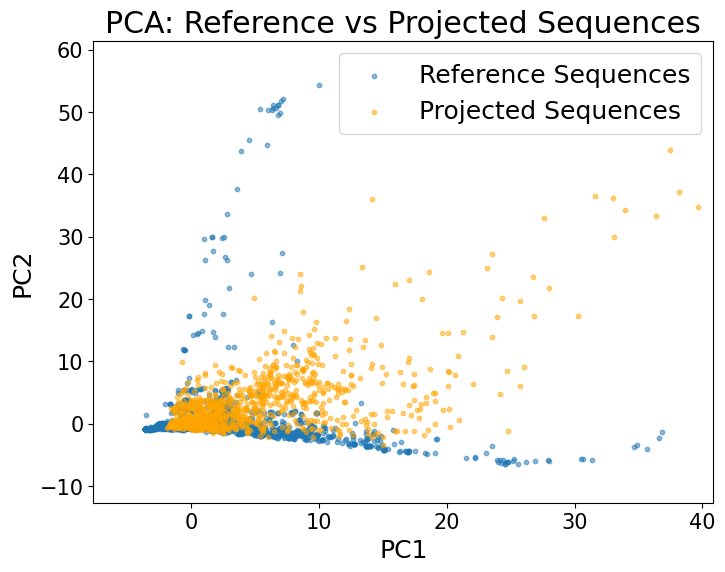

In [ ]:
# load generated sequences
gen_seqs = np.load(os.path.join(save_dir, f'{save_name}.npy'))
print(f"Generated {len(gen_seqs)} sequences.")
print("train_seqs:", len(train_seqs))
print("shapes:", gen_seqs.shape)
# keep only first 53 columns of train_seqs
train_seqs = train_seqs[:, :53]
plot_projected_pca(train_seqs,gen_seqs)

# WITH JDOMS

In [96]:
J_jl = np.load('JDOMS/J_tensor.npy')
print(J_jl.shape)

(21, 21, 63, 63)


In [2]:
# load J_tens from Q,K,V in results
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from dcascore import attention_heads_from_model
from utils import quickread 

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_youss/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_youss/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_youss/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]
model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
print(f"Q shape: {Q_1.shape}, K shape: {K_1.shape}, V shape: {V_1.shape}")
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)
i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
W = W * mask
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)


/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src
Current directory: /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST
Q shape: torch.Size([64, 10, 63]), K shape: torch.Size([64, 10, 63]), V shape: torch.Size([64, 21, 21])
torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [8]:
class SequencePLMvec:
    def __init__(self, J, initial_sequence = None, beta = 1):
        """
        Initialize the SequencePLM object with a coupling tensor J of the family and an optional initial sequence.
        """
        self.J = J
        #self.L = J.shape[-1]
        self.beta = beta
        self.L = J.shape[-1]
        if initial_sequence is None:
            self.sequence = np.random.choice(np.arange(21), self.L) # Sequence of ints (1 to 21) 
        else:
            self.sequence = initial_sequence

    def plm_calc(self, site, trial_aa):
        """
        Compute unnormalized pseudo-likelihood of trial_aa at a given site.
        site: int from 0 to L-1
        trial_aa: int from 0 to 21 (amino acid index)
        """
        if site < 0 or site >= self.L:
            raise ValueError(f"Site {site} is out of bounds for sequence length {self.L}.")
        sum_energy = 0.0
        for j in range(self.L):
            if j == site:
                continue
            aa_j = self.sequence[j]
            sum_energy += self.beta * self.J[trial_aa, aa_j, site, j] # check indexing
            #sum_energy += self.J[aa_j, trial_aa, j, site]
        prob = sum_energy
        return prob

    def plm_site_distribution(self, site):
        """
        Compute probability distriution for specific site (normalized)
        """
        probs = []
        for trial_aa in range(21):
            probs.append(self.plm_calc(site, trial_aa))
        probs = np.array(probs)
        probs = np.exp(probs-probs.max()) #to avoid overflow for high beta
        probs /= probs.sum()
        return probs
    
    def plm_site_distribution_vectorized(self, site):
        """
        Compute normalized probability distribution for a specific site.
        Fully vectorized over amino acids.
        """
        if site < 0 or site >= self.L:
            raise ValueError(f"Site {site} is out of bounds for sequence length {self.L}.")

        # Indices of other sites
        mask = np.arange(self.L) != site
        other_sites = np.arange(self.L)[mask]
        aa_vector = self.sequence[mask]

        # Energies for all trial amino acids at once
        trial_aas = np.arange(21)[:, None]  # shape (21,1)
        energies = self.J[trial_aas, aa_vector, site, other_sites]  # shape (21, L-1)
        sum_energy = self.beta * np.sum(energies, axis=1)  # shape (21,)

        # Softmax with numerical stability
        probs = np.exp(sum_energy - np.max(sum_energy))
        probs /= probs.sum()
        return probs
    
    def check_vectorized(self, site):
        """
        Check that vectorized and loop implementations give same result
        """
        probs_loop = self.plm_site_distribution(site)
        probs_vec = self.plm_site_distribution_vectorized(site)
        assert np.allclose(probs_loop, probs_vec), f"Mismatch at site {site}"
        print(f"Vectorized check passed at site {site}")
    
    def draw_aa(self, site, vec=True):
        """
        Sample a new AA at the given site from PLM distribution
        """
        if vec:
            probs = self.plm_site_distribution_vectorized(site)
        else:
            probs = self.plm_site_distribution(site)
        new_aa = np.random.choice(21, p=probs) # aa from 0 to 20
        self.sequence[site] = new_aa

    def update_PCA_coords(self, model, plot=False):
        """
        Jointly update both PCA coordinates using Boltzmann sampling
        based on PLM-derived J_PCA tensor and the current amino acid sequence.

        Assumes: nb_PCA_comp == 2
        """
        #if self.J_PCA is None:
        #    raise ValueError("J_PCA not provided in model.")
        #if self.nb_PCA_comp != 2:
        #    raise ValueError(f"Joint 2D PCA update only supports 2 PCA components, got {self.nb_PCA_comp}.")

        L = self.L
        Nbins = 35
        offset = L  # Start index of PCA coords in self.sequence
        probs_2D = np.zeros((Nbins, Nbins))
        energies_2D = self.compute_coord_energy(model)

        # Numerically stable softmax
        shifted_energies = self.beta_PCA * energies_2D #(energy should be -)
        #shifted_energies -= shifted_energies.max()

        shifted_energies -= shifted_energies.max()  # subtract max for numerical stability

        probs_2D = np.exp(-shifted_energies)
        total = probs_2D.sum()

        # Check for numerical issues
        if total == 0 or np.isnan(total) or np.isinf(total):
            probs_2D = np.ones_like(probs_2D) / probs_2D.size  # uniform distribution
        else:
            probs_2D /= total

        # Sample from joint distribution
        flat_probs = probs_2D.flatten()
        choice = np.random.choice(Nbins * Nbins, p=flat_probs)
        i_sampled, j_sampled = np.unravel_index(choice, (Nbins, Nbins))

        self.sequence[offset + 0] = i_sampled  # PCA comp 0
        self.sequence[offset + 1] = j_sampled  # PCA comp 1

        return np.array([i_sampled, j_sampled])

    def seq_energy(self):
        sum=0
        for i in range(self.L):
            for j in range(self.L):
                sum+=self.J[self.sequence[i], self.sequence[j],i,j]
        return sum

In [ ]:
class BatchSequencePLMvec:
    def __init__(self, J, N, beta=1, nb_PCA_comp=0, PCA_component_list=None, J_tens_PCA=None, beta_PCA=1):
        """
        Initialize with a batch of N independent sequences.
        """
        self.J = J
        self.J_PCA = J_tens_PCA
        self.beta = beta
        self.beta_PCA = beta_PCA
        self.nb_PCA_comp = nb_PCA_comp
        self.N = N

        if self.J_PCA is not None:
            self.L = J.shape[-1] - nb_PCA_comp
        else:
            self.L = J.shape[-1] - nb_PCA_comp

        # Initialize N random sequences
        core_sequences = np.random.randint(0, 21, size=(N, self.L))

        if nb_PCA_comp > 0:
            if PCA_component_list is None:
                raise ValueError("PCA_component_list must be provided for PCA components.")
            if len(PCA_component_list) != nb_PCA_comp:
                raise ValueError("Mismatch between number of PCA components and list provided.")
            pca_array = np.tile(PCA_component_list, (N, 1))  # replicate for each sequence
            self.sequences = np.concatenate((core_sequences, pca_array), axis=1)
        else:
            self.sequences = core_sequences  # shape: (N, L [+ nb_PCA])

    def plm_calc_batch(self, site, trial_aa):
        """
        Compute unnormalized pseudo-likelihood for all N sequences at one site and one trial AA.
        Return: (N,) array
        """
        aa_j_all = self.sequences[:, :self.L]  # shape (N, L)
        aa_trial = np.full(self.N, trial_aa)

        energy = np.zeros(self.N)

        for j in range(self.L):
            if j == site:
                continue
            aa_j = aa_j_all[:, j]  # shape (N,)
            energy += self.beta * np.asarray(self.J[trial_aa, aa_j, site, j])  # vectorized lookup

        # If PCA is used
        if self.nb_PCA_comp > 0:
            for i in range(self.nb_PCA_comp):
                PCA_coord = self.sequences[:, self.L + i]
                if self.J_PCA is not None:
                    energy += self.beta_PCA * np.asarray(self.J_PCA[trial_aa, PCA_coord, site, i])
                else:
                    energy += self.beta_PCA * np.asarray(self.J[trial_aa, PCA_coord, site, self.L + i])
        
        return energy
    
    def plm_calc_batch_vec(self, site, trial_aa):
        """
        Vectorized computation of unnormalized pseudo-likelihood for all N sequences
        at one site and one trial AA. Returns (N,) array.
        """
        # All AA at other sites
        mask = np.arange(self.L) != site
        aa_j_all = self.sequences[:, :self.L]  # shape (N, L)
        aa_vector = aa_j_all[:, mask]          # shape (N, L-1)
        sites_vector = np.arange(self.L)[mask] # shape (L-1,)

        # Use fancy indexing to get J[trial_aa, aa_vector, site, sites_vector] for all sequences
        # We'll broadcast trial_aa over N sequences
        energy = np.sum(self.beta * self.J[trial_aa, aa_vector, site, sites_vector], axis=1)

        # Optional PCA contribution
        if self.nb_PCA_comp > 0:
            for i in range(self.nb_PCA_comp):
                PCA_coord = self.sequences[:, self.L + i]
                if self.J_PCA is not None:
                    energy += self.beta_PCA * self.J_PCA[trial_aa, PCA_coord, site, i]
                else:
                    energy += self.beta_PCA * self.J[trial_aa, PCA_coord, site, self.L + i]

        return energy

    def plm_site_distribution_batch(self, site):
        """
        Compute PLM probabilities for each AA (0..20) for all N sequences at site.
        Returns: (N, 21) array of probabilities
        """
        raw_scores = np.zeros((self.N, 21))
        for aa in range(21):
            raw_scores[:, aa] = self.plm_calc_batch(site, aa)

        raw_scores -= raw_scores.max(axis=1, keepdims=True)  # stability
        probs = np.exp(raw_scores)
        probs /= probs.sum(axis=1, keepdims=True)  # normalize
        return probs  # shape: (N, 21)

    def plm_site_distribution_batch_vec(self, site):
        """
        Fully vectorized computation of PLM probabilities for all N sequences at one site.
        Returns array of shape (N, 21), no explicit loops over amino acids or sequences.
        """
        N = self.N
        L = self.L

        # Indices of other sites
        mask = np.arange(L) != site
        sites_vector = np.arange(L)[mask]        # shape (L-1,)
        aa_vector = self.sequences[:, mask]      # shape (N, L-1)

        # Trial amino acids 0..20, shape (21,1,1) for broadcasting
        trial_aa = np.arange(21)[:, None, None]  # shape (21,1,1)

        # Fancy indexing: J[trial_aa, aa_vector, site, sites_vector] -> shape (21, N, L-1)
        energy_matrix = self.J[trial_aa, aa_vector[None, :, :], site, sites_vector[None, :]] * self.beta

        # Sum over other sites (axis=2) -> shape (21, N), then transpose to (N,21)
        energies = np.sum(energy_matrix, axis=2).T  # shape (N,21)

        # Optional PCA contributions
        if self.nb_PCA_comp > 0:
            for i in range(self.nb_PCA_comp):
                PCA_coord = self.sequences[:, L + i]  # shape (N,)
                if self.J_PCA is not None:
                    energies += (self.beta_PCA * self.J_PCA[:, PCA_coord, site, i].T)
                else:
                    energies += (self.beta_PCA * self.J[:, PCA_coord, site, L + i].T)

        # Softmax with numerical stability
        energies -= energies.max(axis=1, keepdims=True)
        probs = np.exp(energies)
        probs /= probs.sum(axis=1, keepdims=True)

        return probs  # shape (N, 21)

    def draw_aa_batch(self, site, vec):
        """
        Sample new AAs for all N sequences at a given site.
        """
        if vec:
            probs = self.plm_site_distribution_batch_vec(site)  # (N, 21)
        else:   
            probs = self.plm_site_distribution_batch(site)  # (N, 21)
        new_aas = np.array([np.random.choice(21, p=p) for p in probs])  # (N,)
        self.sequences[:, site] = new_aas

    def draw_aa_batch_vec_fast(self, site):
        """
        Vectorized sampling of new AAs for all N sequences at a given site, fully in NumPy.
        """
        probs = self.plm_site_distribution_batch_vec(site)  # shape (N, 21)

        # Cumulative probabilities
        cum_probs = np.cumsum(probs, axis=1)  # shape (N, 21)

        # Uniform random numbers for each sequence
        r = np.random.rand(self.N)  # shape (N,)

        # Choose the first AA where cumulative prob >= r
        new_aas = np.argmax(cum_probs >= r[:, None], axis=1)

        self.sequences[:, site] = new_aas

    def evolve_all(self, n_iter=500, vec=True):
        """
        Perform Gibbs sampling over all sequences for n_iter iterations.
        """
        for _ in tqdm(range(n_iter)):
            site=np.random.choice(self.L)
            #self.draw_aa_batch(site,vec=vec)
            self.draw_aa_batch_vec_fast(site)

    def get_sequences(self):
        """
        Return all N sequences.
        """
        return self.sequences

    def to_letters(self):
        """
        Return N sequences in letter format.
        """
        num_to_letter = {v: k for k, v in letter_to_num.items()}
        letter_seqs = []
        for seq in self.sequences[:, :self.L]:
            letter_seq = ''.join([num_to_letter[i] for i in seq])
            letter_seqs.append(letter_seq)
        return letter_seqs
    def check_vectorization(self, site, atol=1e-12):
        """
        Verify that the vectorized PLM site distribution matches the original non-vectorized version
        for a given site.
        
        Parameters
        ----------
        site : int
            Site index to test.
        atol : float
            Absolute tolerance for comparison.
        """
        # Original non-vectorized probabilities
        probs_old = self.plm_site_distribution_batch(site)  # shape (N, 21)

        # Vectorized probabilities
        probs_vec = self.plm_site_distribution_batch_vec(site)  # shape (N, 21)

        # Compare
        if np.allclose(probs_old, probs_vec, atol=atol):
            print(f"PASS: Vectorized distribution matches non-vectorized version for site {site}.")
        else:
            diff = np.abs(probs_old - probs_vec).max()
            print(f"FAIL: Max difference {diff} at site {site}")

In [35]:
def sample_site_low_coupling(seq, epsilon=1e-12):
    # Vectorized coupling strengths
    abs_couplings = np.sum(np.abs(seq.J), axis=(0,1))  # shape (L,L)
    np.fill_diagonal(abs_couplings, 0)
    site_strengths = np.sum(abs_couplings, axis=1)  # shape (L,)

    # Convert to probabilities: lower coupling → higher probability
    inv_strengths = 1.0 / (site_strengths + epsilon)
    probs = inv_strengths / inv_strengths.sum()

    # Sample site according to probabilities
    site = np.random.choice(seq.L, p=probs)
    return site

In [ ]:
from tqdm import tqdm
import numpy as np

def generate_plm(J, N_seqs=40000, init_sequence=None, beta=1, site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta)

    for _ in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:
            site = site_selector(seq)        # custom site selection
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())

    return np.array(gen_sequences)


def generate_plm_vect(J,n_iter, init_sequence=500,beta=1,nb_PCA_comp=0,PCA_comp_list=np.array([]),J_PCA=None,beta_PCA=1):
    """
    Generate N_seqs new sequences using PLM (random initialization by default)
    """
    batch_model = BatchSequencePLMvec(J, init_sequence,beta=beta,nb_PCA_comp=nb_PCA_comp,PCA_component_list=PCA_comp_list,J_tens_PCA=J_PCA,beta_PCA=beta_PCA)
    batch_model.evolve_all(n_iter=n_iter)
    sequences = batch_model.get_sequences()  # shape: (1000, L)
    return sequences


In [71]:
plm_gen_seqs_batch = generate_plm_vect(Jtens.numpy(), n_iter=5, init_sequence=2, beta=1)

100%|██████████| 5/5 [00:00<00:00, 1984.06it/s]


PASS: Vectorized distribution matches non-vectorized version for site 0.
PASS: Vectorized distribution matches non-vectorized version for site 1.
PASS: Vectorized distribution matches non-vectorized version for site 2.
PASS: Vectorized distribution matches non-vectorized version for site 3.
PASS: Vectorized distribution matches non-vectorized version for site 4.
PASS: Vectorized distribution matches non-vectorized version for site 5.
PASS: Vectorized distribution matches non-vectorized version for site 6.
PASS: Vectorized distribution matches non-vectorized version for site 7.
PASS: Vectorized distribution matches non-vectorized version for site 8.
PASS: Vectorized distribution matches non-vectorized version for site 9.
PASS: Vectorized distribution matches non-vectorized version for site 10.
PASS: Vectorized distribution matches non-vectorized version for site 11.
PASS: Vectorized distribution matches non-vectorized version for site 12.
PASS: Vectorized distribution matches non-vector

In [75]:
Nseqs = 1000
plm_gen_seqs = []
for _ in tqdm(range(Nseqs)):
    batch = generate_plm(Jtens.numpy(), N_seqs=2000, init_sequence=None, beta=1, site_selector=None)
    last_seq = batch[-1]  # pick only the last sequence in this batch
    plm_gen_seqs.append(last_seq)
plm_gen_seqs = np.array(plm_gen_seqs)
print(plm_gen_seqs.shape)

100%|██████████| 1000/1000 [04:05<00:00,  4.07it/s]

(1000, 63)


In [102]:
def plm_site_distribution_batch_vec_full(sequences, J, site, beta=1.0, J_PCA=None, nb_PCA_comp=0, beta_PCA=1.0):
    """
    Fully vectorized computation of PLM probabilities for all sequences at one site.
    
    Parameters
    ----------
    sequences : np.ndarray
        Array of shape (N, L + nb_PCA_comp) containing current sequences.
        First L columns: amino acids 0..20
        Optional PCA coordinates in remaining columns.
    J : np.ndarray
        Coupling tensor, shape (21, 21, L, L)
    site : int
        Site index to update
    beta : float
        Inverse temperature
    J_PCA : np.ndarray, optional
        Couplings for PCA components, shape (21, ?, L, nb_PCA_comp)
    nb_PCA_comp : int
        Number of PCA components
    beta_PCA : float
        Weight for PCA contributions
    
    Returns
    -------
    probs : np.ndarray
        Array of shape (N, 21) with probabilities for each amino acid at `site`
    """
    N, L_total = sequences.shape
    L = L_total - nb_PCA_comp

    # Indices of other sites
    mask = np.arange(L) != site
    sites_vector = np.arange(L)[mask]           # shape (L-1,)
    aa_vector = sequences[:, mask]              # shape (N, L-1)

    # Trial amino acids 0..20
    trial_aa = np.arange(21)[:, None, None]    # shape (21,1,1)

    # Fancy indexing: J[trial_aa, aa_vector, site, sites_vector] -> shape (21, N, L-1)
    energy_matrix = J[trial_aa, aa_vector[None, :, :], site, sites_vector[None, :]] * beta

    # Sum over other sites
    energies = np.sum(energy_matrix, axis=2).T  # shape (N,21)

    # PCA contributions
    if nb_PCA_comp > 0:
        PCA_coords = sequences[:, L:L+nb_PCA_comp]  # shape (N, nb_PCA_comp)
        if J_PCA is not None:
            # Broadcast over trial amino acids and PCA components
            energies += np.sum(beta_PCA * J_PCA[trial_aa[:, None, None], PCA_coords[None, :, :], site, np.arange(nb_PCA_comp)[:, None]], axis=0)
        else:
            # Fallback: use main J tensor for PCA sites
            energies += np.sum(beta_PCA * J[trial_aa[:, None, None], PCA_coords[None, :, :], site, np.arange(L, L+nb_PCA_comp)[None, :]], axis=0)

    # Softmax with numerical stability
    energies -= energies.max(axis=1, keepdims=True)
    probs = np.exp(energies)
    probs /= probs.sum(axis=1, keepdims=True)

    return probs  # shape (N, 21)



def generate_plm_last_seq(J, Nseqs=1000, steps=2000, beta=1):
    """
    Generate Nseqs sequences, each evolved for 'steps' iterations.
    Returns only the final sequence for each.
    """
    L = J.shape[2]  # sequence length
    sequences = np.random.randint(21, size=(Nseqs, L))  # random initialization

    for _ in tqdm(range(steps)):
        # pick random site per iteration (could vectorize multiple sites if desired)
        site = np.random.randint(L)
        
        # compute PLM probabilities for all sequences at this site
        probs = plm_site_distribution_batch_vec_full(sequences, J, site, beta)  # vectorized
        
        # vectorized sampling
        cum_probs = np.cumsum(probs, axis=1)
        r = np.random.rand(Nseqs)
        sequences[:, site] = np.argmax(cum_probs >= r[:, None], axis=1)

    return sequences

gen_seqs_last_jl = generate_plm_last_seq(Jtens.numpy(), Nseqs=10000, steps=1500, beta=1)
print(gen_seqs_last_jl.shape)

 15%|█▍        | 219/1500 [00:16<01:39, 12.94it/s]


KeyboardInterrupt: 

In [85]:
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from seq_utils import load_train_seqs
#from Frquencies_plot_func import plot_frequencies_aa_pos,plot_corr_aa_pos
sys.path.pop(0)  # Removes the parent_dir from sys.path

train_seqs = load_train_seqs(mac=True) 
train_seqs_num = [letters_to_nums(seq) for seq in train_seqs]
train_seqs_num = np.array(train_seqs_num)
print(train_seqs_num.shape)

Loaded 14502 training sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta
(14502, 63)


gen seqs: 15000
gen seqs decorr: 15000


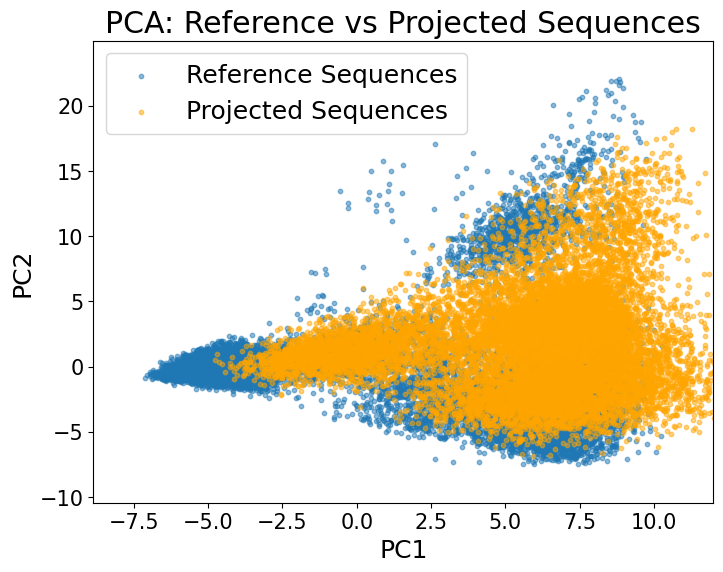

In [100]:
# plot taking 1 every 10000 sequences
print('gen seqs:', len(gen_seqs_last))
# decorrelate by taking 1 every 500 sequences
gen_seqs_decorr = gen_seqs_last
print('gen seqs decorr:', len(gen_seqs_decorr))
plot_projected_pca(train_seqs,gen_seqs_decorr)

In [87]:
# frequency comparison
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

In [88]:
Z,W = quickread('/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')
print(Z.shape)

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37261326373297793
Computed theta: 0.3263437237358812


100%|██████████| 14502/14502 [00:09<00:00, 1521.09it/s]

3265.70225762244
(63, 14502)


In [93]:
f_train = compute_empirical_freqs(Z, W, q=21)
print(f_train.shape)
f_sampled = compute_empirical_freqs(gen_seqs_decorr.T, None, q=21)
print(f_sampled.shape)

(21, 63)
(21, 63)


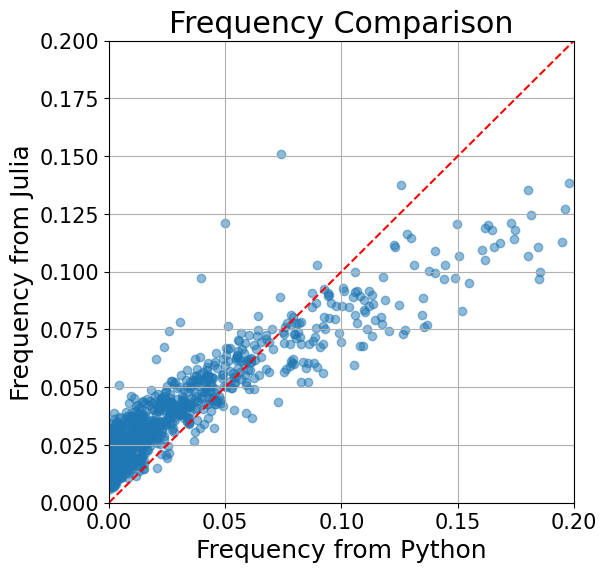

In [94]:
# freq-freq plot
from matplotlib import pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(f_train, f_sampled, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

In [ ]:
save_dir = 'jdoms_J_jl'
#Nbins=35
Nseqs=3000
b = 1
#target = (14, 12)  # Example target coordinates
init_sequence = 3000
save_name = f'gen_{init_sequence}_{Nseqs}_{b}'
generated_sequences = generate_plm_vect_n_save(save_dir, save_name, J_jl, init_sequence=init_sequence, n_iter=Nseqs, beta=b, beta_PCA=0)

Generated 3000 sequences.
train_seqs: 14502
shapes: (3000, 63)


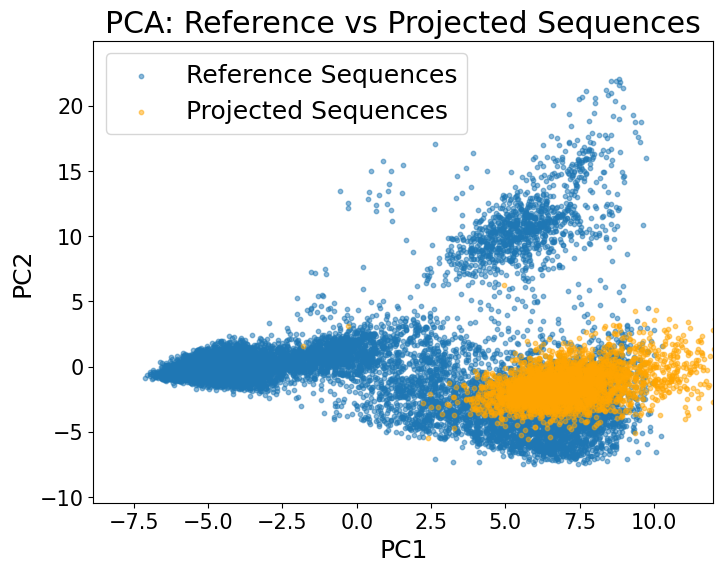

In [ ]:
# load generated sequences
gen_seqs_jl = np.load(os.path.join(save_dir, f'{save_name}.npy'))
print(f"Generated {len(gen_seqs_jl)} sequences.")
print("train_seqs:", len(train_seqs))
print("shapes:", gen_seqs_jl.shape)
# keep only first 53 columns of train_seqs
plot_projected_pca(train_seqs,gen_seqs_jl)

In [ ]:
save_dir = 'jdoms_J_py'
#Nbins=35
Nseqs=3000
b = 1
#target = (14, 12)  # Example target coordinates
init_sequence = 3000
save_name = f'gen_{init_sequence}_{Nseqs}_{b}'
generated_sequences = generate_plm_vect_n_save(save_dir, save_name, Jtens_py, init_sequence=init_sequence, n_iter=Nseqs, beta=b, beta_PCA=0)

Generated 3000 sequences.
train_seqs: 14502
shapes: (3000, 63)


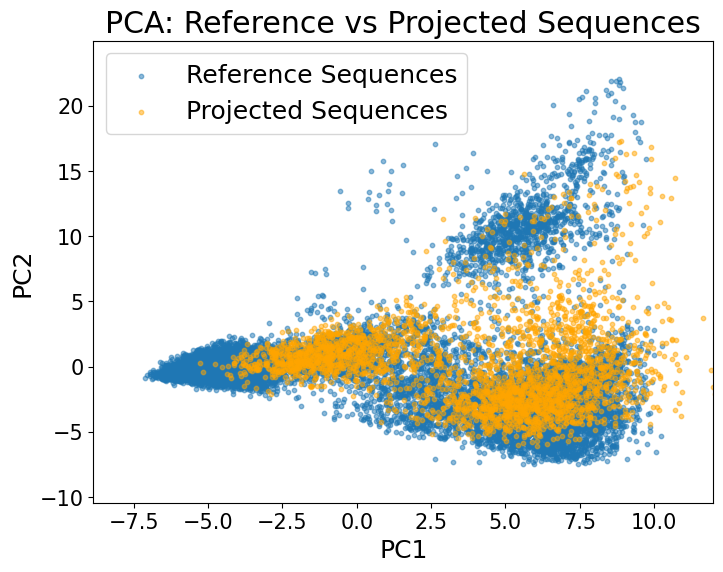

In [ ]:
# load generated sequences
gen_seqs_py = np.load(os.path.join(save_dir, f'{save_name}.npy'))
print(f"Generated {len(gen_seqs_py)} sequences.")
print("train_seqs:", len(train_seqs))
print("shapes:", gen_seqs_py.shape)
# keep only first 53 columns of train_seqs
plot_projected_pca(train_seqs,gen_seqs_py)

## FREQS

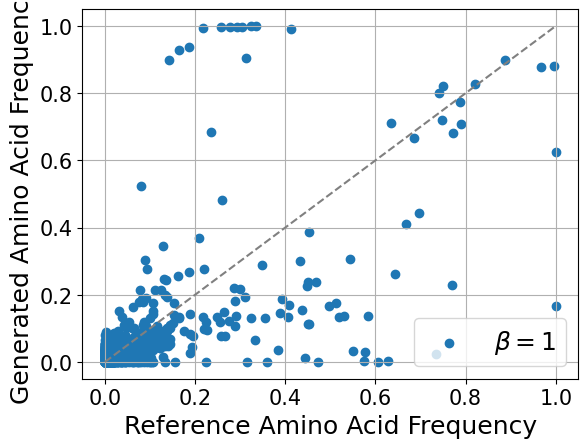

In [ ]:
save_path = 'jdoms_J_jl'
plot_frequencies_aa_pos(gen_seqs_jl,train_seqs_num,beta=b)
#plot_corr_aa_pos(gen_seqs_jl,np.array(train_seqs_num))

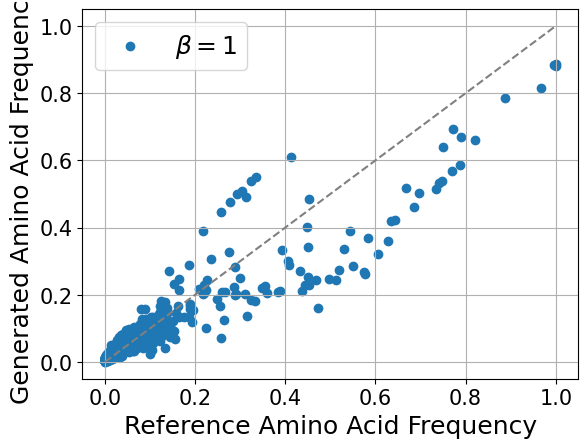

In [ ]:
save_path = 'jdoms_J_py'
plot_frequencies_aa_pos(gen_seqs_py,train_seqs_num,beta=b)
#plot_corr_aa_pos(gen_seqs_jl,np.array(train_seqs_num))

In [ ]:
# load J_tens from Q,K,V in results
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from dcascore import attention_heads_from_model

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = os.getcwd()
Q_1 = read_tensor_from_txt( cwd +"/JDOMS/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/JDOMS/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/JDOMS/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]
model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
print(f"Q shape: {Q_1.shape}, K shape: {K_1.shape}, V shape: {V_1.shape}")
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)
i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
W = W * mask
# Compute Jtens
Jtens_ale = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens_ale.shape[0]
N = Jtens_ale.shape[2]
print(q)
print(N)
print(Jtens_ale.shape)


/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src
Current directory: /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST


ValueError: invalid literal for int() with base 10: '0.9823974526998731'

## Check frequency plots

In [ ]:
import numpy as np
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

[[0.57142857 0.57142857 0.28571429]
 [0.42857143 0.42857143 0.71428571]]


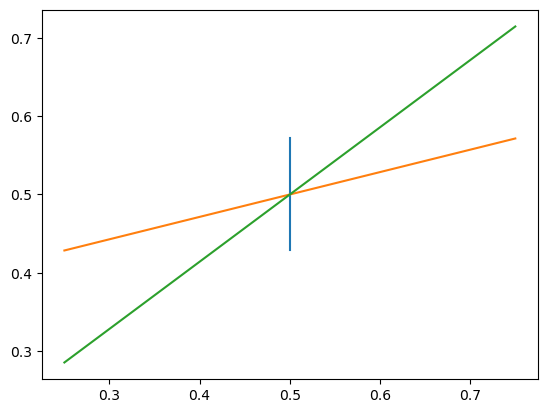

In [ ]:
# test function on toy example - Z is 4 sequences, 4 positions, q=2
from matplotlib.pyplot import plot


Z = np.array([[1, 2, 1, 2],
              [1, 1, 2, 1],
              [2, 1, 2, 2]])
W = np.array([0.5, 1.0, 1.5, 0.5])
q = 2
f = compute_empirical_freqs(Z, W, q)
print(f)

Z2 = np.array([[1, 2, 1, 2],
                [1, 1, 2, 1],
                [2, 1, 2, 2]])
f2 = compute_empirical_freqs(Z2, W=None, q=2)

plot(f2, f)